The antenna, as soon as it was made was connected to the spectrum analyzer inside the lab

Resonant frequency-Where the antenna naturally resonates (X ≈ 0)
SWR(Standing Wave Ratio) - a measure of how well the impedance of an antenna is matched to the impedance of the transmission line
Return loss - How much power is reflected vs accepted
Impedance (R + jX) - Whether the antenna is inductive or capacitive
Smith chart - Full RF behavior in one plot
Bandwidth - Where SWR < 2

A Smith chart tells you, at every frequency:

✔ How well your antenna is matched

✔ What the impedance is (R + jX)

✔ Whether the antenna is inductive or capacitive

✔ How far it is from 50 Ω

✔ How S11 changes with frequency

It is the most compact way to visualize everything about S11 in one plot.

In [18]:
#scikit-rf) is a library made specially for RF/VNA/S-parameter data.
!pip install scikit-rf


In [4]:
import skrf as rf
#rf.Network(...) loads Touchstone S1P file into an RF network object.
ntw = rf.Network('S1P1ananya150.s1p')
ntw
#ntw now contains: frequency points, S11 complex values, impedance, Smith chart data


1-Port Network: 'S1P1ananya150',  50000000.0-150000000.0 Hz, 201 pts, z0=[50.+0.j]

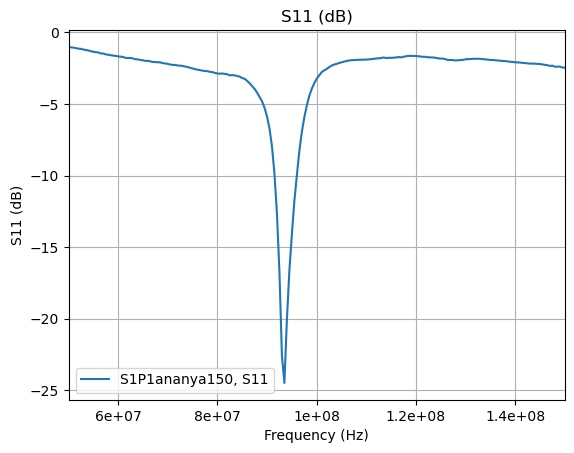

In [20]:
import matplotlib.pyplot as plt

ntw.plot_s_db() #S11(dB)=20log10​∣S11∣
plt.title("S11 (dB)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("S11 (dB)")
plt.grid(True)
plt.show()


SWR = 1 is perfect

SWR = 2 is OK

SWR > 3 is poor

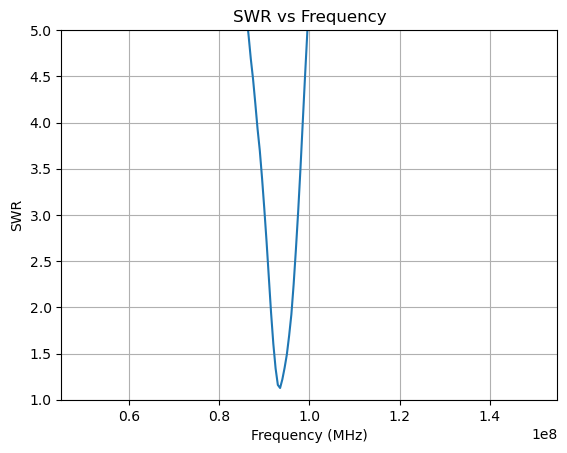

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Compute |S11|
s11 = ntw.s[:,0,0]
mag = np.abs(s11)

# Compute SWR
swr = (1 + mag) / (1 - mag)

# Frequency (in MHz)
freq_mhz = ntw.f

plt.plot(freq_mhz, swr)
plt.title("SWR vs Frequency")
plt.xlabel("Frequency (MHz)")
plt.ylabel("SWR")
plt.grid(True)
plt.ylim(1, 5)   # adjust if needed
plt.show()


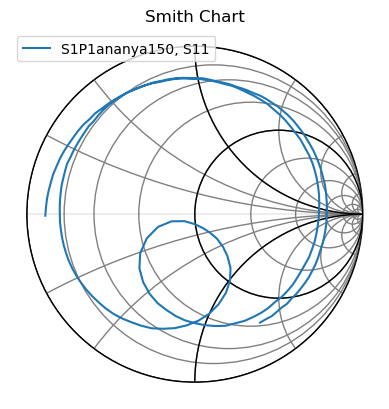

In [26]:
ntw.plot_s_smith()
plt.title("Smith Chart")
plt.show()


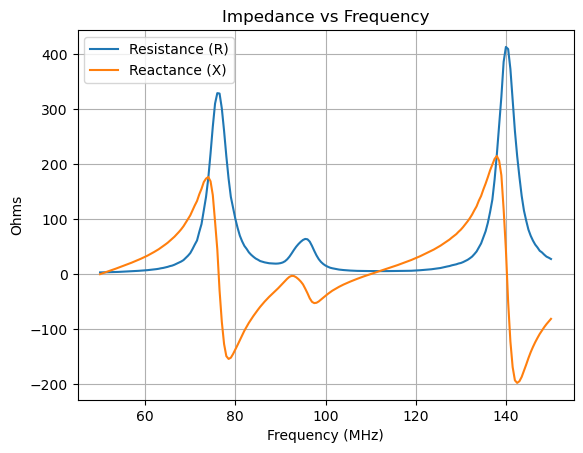

In [12]:
# Extract impedance
impedance = ntw.z[:,0,0]

# Real and imaginary parts
freq = ntw.f
R = impedance.real
X = impedance.imag

# Plot impedance
plt.plot(freq/1e6, R, label='Resistance (R)')
plt.plot(freq/1e6, X, label='Reactance (X)')
plt.title("Impedance vs Frequency")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Ohms")
plt.grid(True)
plt.legend()
plt.show()


In [14]:
import numpy as np

idx = np.argmin(np.abs(X))   # smallest reactance
print("Resonant Frequency ~", freq[idx]/1e6, "MHz")
print("Impedance at resonance:", impedance[idx])


Resonant Frequency ~ 110.0 MHz
Impedance at resonance: (5.4476572866021415-0.08669498453740385j)
